# BEED — Exploratory Data Analysis
Bangalore EEG Epilepsy Dataset · 4-class seizure classification

In [1]:
import sys
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal

from src.beed.data import load_raw, split
from src.beed.config import CLASS_LABELS, CHANNEL_NAMES, SAMPLING_RATE, FIGURES

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load & basic inspection

In [2]:
df = load_raw()
print(f'Shape : {df.shape}')
print(f'Classes: {sorted(df["y"].unique())}')
df.head()

Shape : (8000, 17)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Fp1,8000.0,-1.49,36.82,-281.0,-7.00,0.0,8.00,252.0
Fp2,8000.0,-2.19,36.11,-255.0,-7.00,0.0,8.00,261.0
F3,8000.0,-3.24,35.80,-255.0,-7.00,-1.0,5.00,238.0
F4,8000.0,-4.12,36.29,-257.0,-10.00,-1.0,7.00,246.0
C3,8000.0,-1.82,37.62,-264.0,-10.00,0.0,10.00,249.0
C4,8000.0,-2.31,36.31,-277.0,-8.00,0.0,8.00,245.0
P3,8000.0,-3.40,36.36,-277.0,-8.00,-1.0,6.00,220.0
P4,8000.0,-3.45,36.52,-260.0,-7.00,-1.0,5.00,271.0
O1,8000.0,-1.65,38.11,-290.0,-7.00,0.0,8.00,280.0
O2,8000.0,-2.56,37.54,-302.0,-8.00,0.0,8.00,251.0


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDtypes: {df.dtypes.value_counts().to_dict()}')

Missing values per column:
Fp1    0
Fp2    0
F3     0
F4     0
C3     0
C4     0
P3     0
P4     0
O1     0
O2     0
F7     0
F8     0
T3     0
T4     0
T5     0
T6     0
y      0
dtype: int64

Dtypes: {dtype('int64'): 17}


## 2. Class distribution

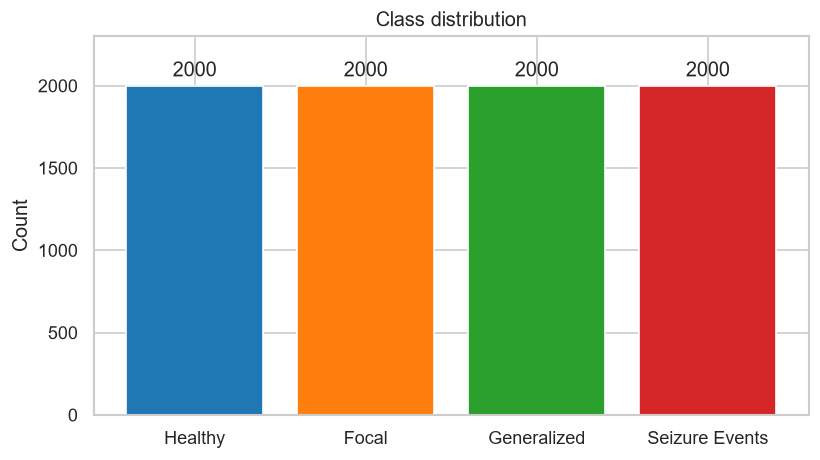

y
Healthy           2000
Focal             2000
Generalized       2000
Seizure Events    2000
Name: count, dtype: int64


In [5]:
counts = df['y'].value_counts().sort_index()
labels = [CLASS_LABELS[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', 4))
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Class distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES / '01_class_distribution.png')
plt.show()
print(counts.rename(CLASS_LABELS))

## 3. Raw EEG traces — one sample per class

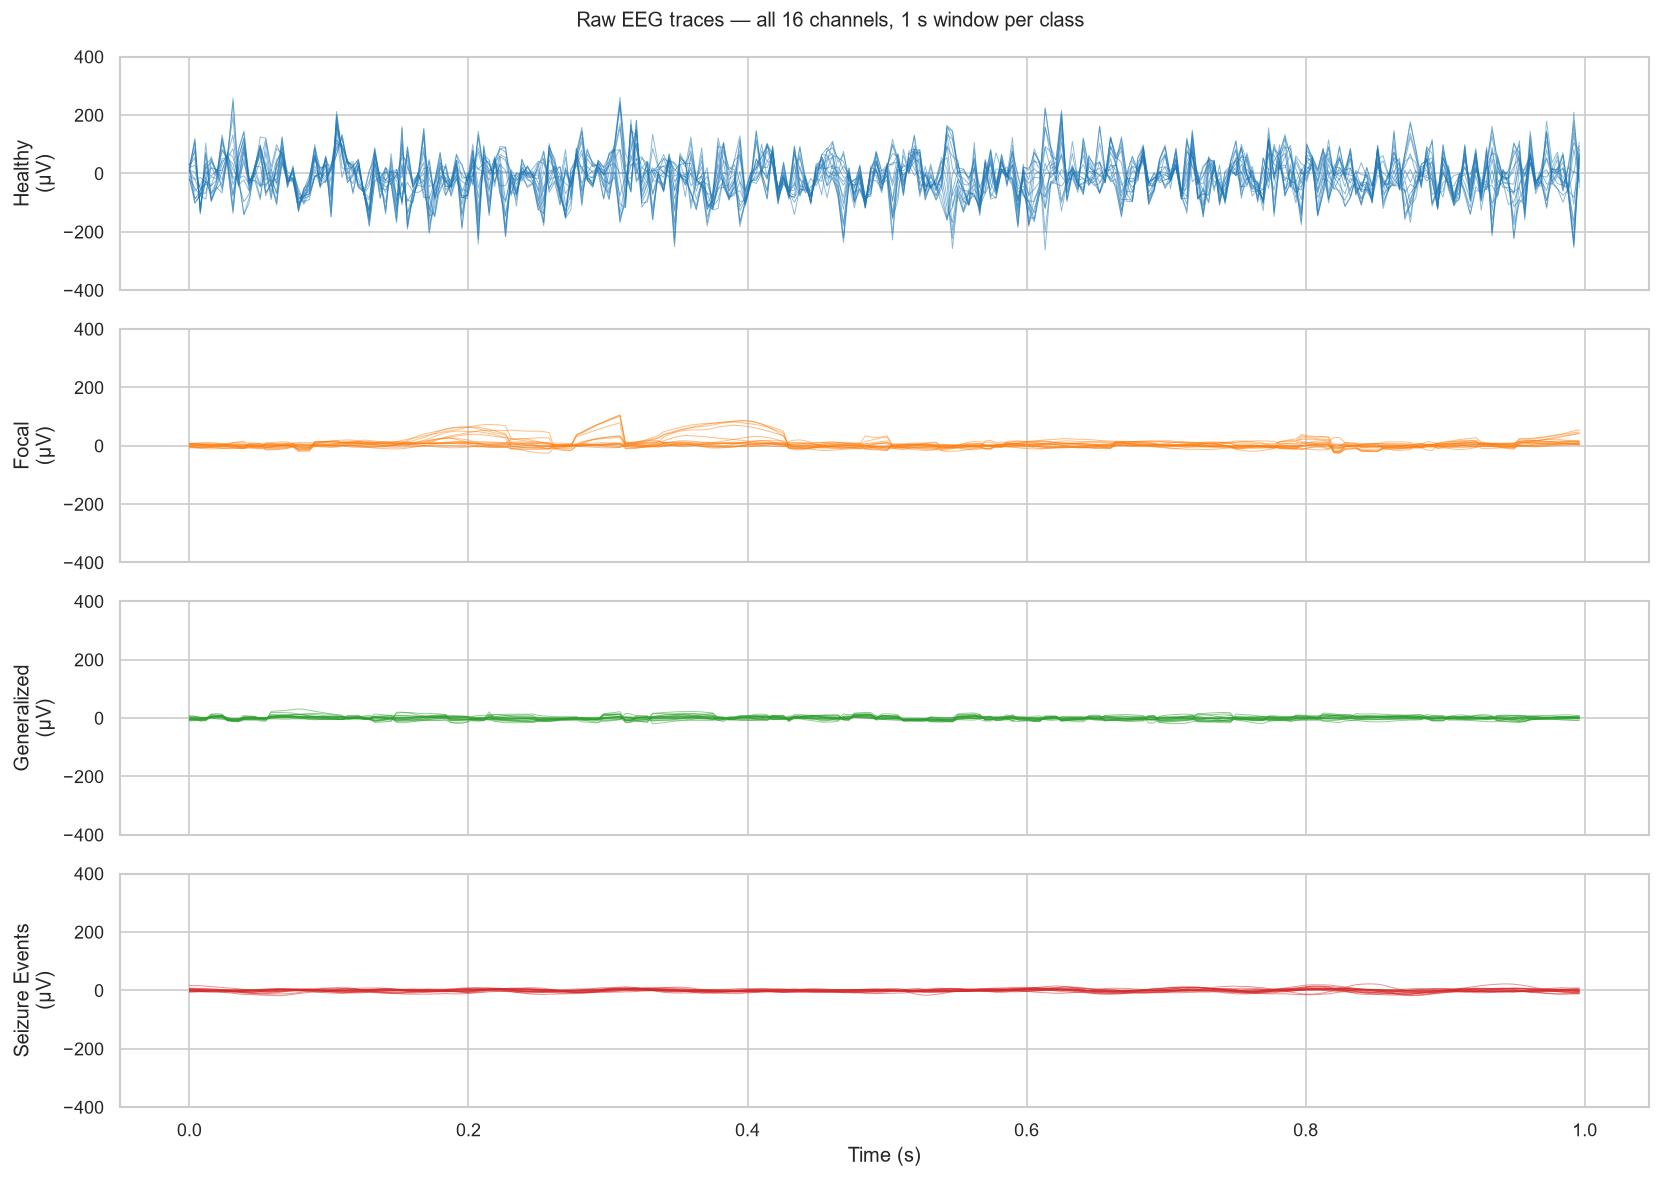

In [6]:
WINDOW = 256  # 1 second at 256 Hz

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
palette = sns.color_palette('tab10', 4)

for cls, ax, color in zip(sorted(df['y'].unique()), axes, palette):
    subset = df[df['y'] == cls].head(WINDOW)
    t = np.arange(len(subset)) / SAMPLING_RATE
    for ch in CHANNEL_NAMES:
        ax.plot(t, subset[ch].values, lw=0.6, alpha=0.5, color=color)
    ax.set_ylabel(f'{CLASS_LABELS[cls]}\n(μV)')
    ax.set_ylim(-400, 400)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw EEG traces — all 16 channels, 1 s window per class', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '02_raw_traces.png')
plt.show()

## 4. Amplitude statistics per class

In [7]:
X = df[CHANNEL_NAMES]
y = df['y']

stats = []
for cls in sorted(y.unique()):
    sub = X[y == cls].values.ravel()
    stats.append({
        'Class': CLASS_LABELS[cls],
        'Mean (μV)': sub.mean().round(2),
        'Std (μV)': sub.std().round(2),
        'Min (μV)': sub.min(),
        'Max (μV)': sub.max(),
        'P5 (μV)': np.percentile(sub, 5).round(1),
        'P95 (μV)': np.percentile(sub, 95).round(1),
    })
pd.DataFrame(stats).set_index('Class')

,Mean (μV),Std (μV),Min (μV),Max (μV),P5 (μV),P95 (μV)
Class,,,,,,
Healthy,-13.28,69.96,-323,296,-129.0,100.0
Focal,1.61,15.09,-73,105,-21.0,26.0
Generalized,-0.38,7.87,-50,103,-11.0,11.0
Seizure Events,0.03,10.20,-58,74,-16.0,16.0


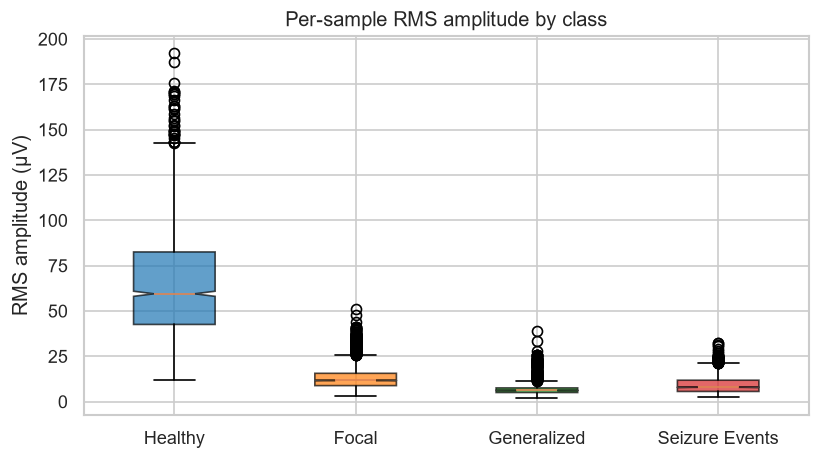

In [8]:
# Boxplot of per-sample RMS per class (root-mean-square across channels)
df['rms'] = np.sqrt((df[CHANNEL_NAMES] ** 2).mean(axis=1))

fig, ax = plt.subplots(figsize=(7, 4))
data_by_class = [df[df['y'] == cls]['rms'].values for cls in sorted(df['y'].unique())]
bp = ax.boxplot(data_by_class, tick_labels=[CLASS_LABELS[c] for c in sorted(df['y'].unique())],
                patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], sns.color_palette('tab10', 4)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('RMS amplitude (μV)')
ax.set_title('Per-sample RMS amplitude by class')
plt.tight_layout()
plt.savefig(FIGURES / '03_rms_by_class.png')
plt.show()

## 5. Power Spectral Density (Welch) by class

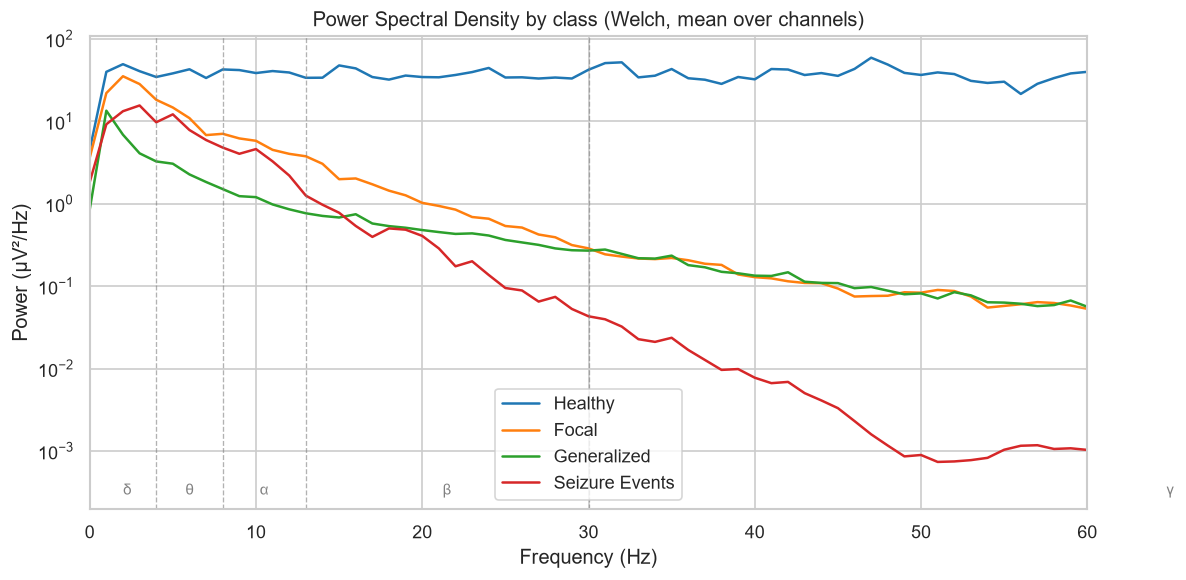

In [9]:
BAND_LINES = [4, 8, 13, 30, 100]  # δ/θ/α/β/γ boundaries
BAND_NAMES = ['δ', 'θ', 'α', 'β', 'γ']

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('tab10', 4)

for cls, color in zip(sorted(df['y'].unique()), palette):
    sub = df[df['y'] == cls][CHANNEL_NAMES].values  # shape (n, 16)
    # average PSD across all channels and samples
    psds = []
    for ch_idx in range(sub.shape[1]):
        f, psd = signal.welch(sub[:, ch_idx], fs=SAMPLING_RATE, nperseg=256)
        psds.append(psd)
    mean_psd = np.mean(psds, axis=0)
    ax.semilogy(f, mean_psd, label=CLASS_LABELS[cls], color=color, lw=1.5)

for b in BAND_LINES:
    ax.axvline(b, color='gray', lw=0.8, ls='--', alpha=0.6)
for i, name in enumerate(BAND_NAMES):
    x = (BAND_LINES[i-1] if i > 0 else 0.5 + BAND_LINES[i]) / 2 if i == 0 else (BAND_LINES[i-1] + BAND_LINES[i]) / 2
    ax.text(x, ax.get_ylim()[0] * 1.5, name, ha='center', fontsize=9, color='gray')

ax.set_xlim(0, 60)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (μV²/Hz)')
ax.set_title('Power Spectral Density by class (Welch, mean over channels)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / '04_psd_by_class.png')
plt.show()

## 6. Channel-wise mean amplitude heatmap

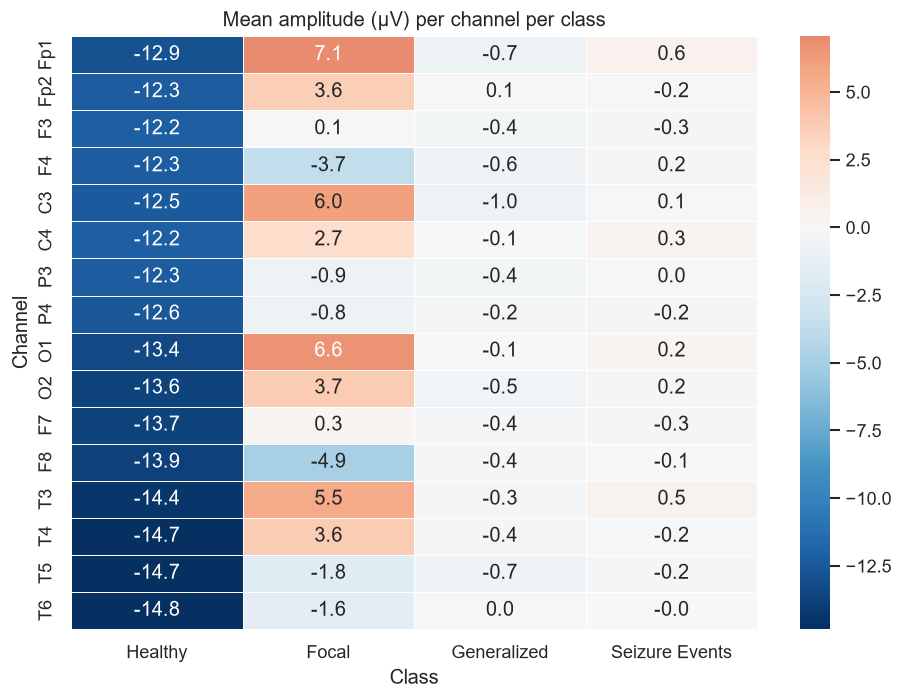

In [10]:
mean_by_class_ch = pd.DataFrame(
    {CLASS_LABELS[cls]: df[df['y'] == cls][CHANNEL_NAMES].mean() for cls in sorted(df['y'].unique())}
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mean_by_class_ch, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Mean amplitude (μV) per channel per class')
ax.set_xlabel('Class')
ax.set_ylabel('Channel')
plt.tight_layout()
plt.savefig(FIGURES / '05_channel_mean_heatmap.png')
plt.show()

## 7. Inter-channel correlation matrix

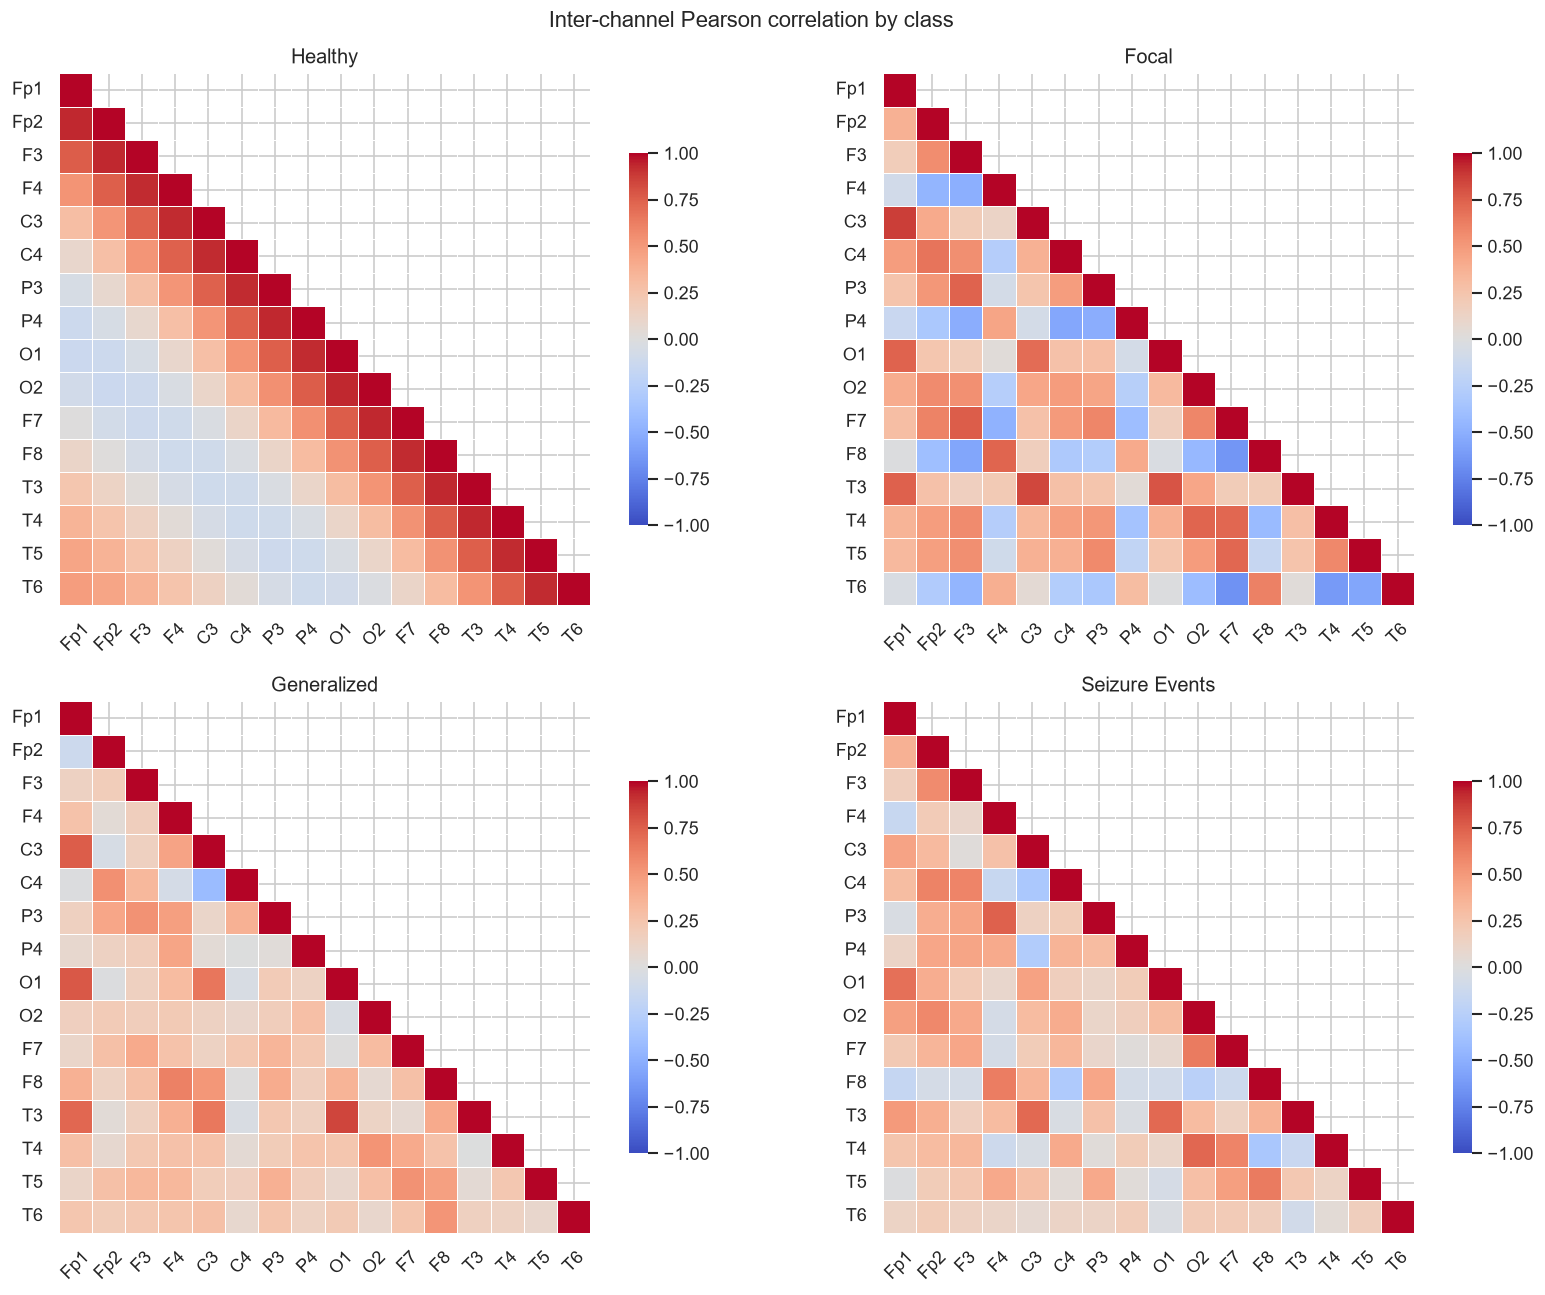

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
palette = sns.color_palette('tab10', 4)

for cls, ax in zip(sorted(df['y'].unique()), axes.ravel()):
    corr = df[df['y'] == cls][CHANNEL_NAMES].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.3, mask=mask,
                xticklabels=CHANNEL_NAMES, yticklabels=CHANNEL_NAMES,
                annot=False, cbar_kws={'shrink': 0.7})
    ax.set_title(CLASS_LABELS[cls])
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Inter-channel Pearson correlation by class', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / '06_channel_correlation.png')
plt.show()

## 8. Train / val / test split check

In [12]:
train, val, test = split(df.drop(columns=['rms']))

print(f'Train : {len(train):5d} rows')
print(f'Val   : {len(val):5d} rows')
print(f'Test  : {len(test):5d} rows')
print()

split_counts = pd.DataFrame({
    'Train': train['y'].value_counts().sort_index().rename(CLASS_LABELS),
    'Val':   val['y'].value_counts().sort_index().rename(CLASS_LABELS),
    'Test':  test['y'].value_counts().sort_index().rename(CLASS_LABELS),
})
print(split_counts)

Train :  5600 rows
Val   :   800 rows
Test  :  1600 rows

                Train  Val  Test
y                               
Healthy          1400  200   400
Focal            1400  200   400
Generalized      1400  200   400
Seizure Events   1400  200   400


## 9. Summary

In [13]:
print('=== EDA Summary ===')
print(f'Rows          : {len(df)}')
print(f'Channels      : {len(CHANNEL_NAMES)}')
print(f'Missing values: {df[CHANNEL_NAMES].isnull().sum().sum()}')
print(f'Amplitude range: [{df[CHANNEL_NAMES].values.min():.0f}, {df[CHANNEL_NAMES].values.max():.0f}] μV')
print(f'Classes balanced: {dict(df["y"].value_counts().sort_index().rename(CLASS_LABELS))}')
print()
print('Saved figures to:', FIGURES)

=== EDA Summary ===
Rows          : 8000
Channels      : 16
Missing values: 0
Amplitude range: [-323, 296] μV
Classes balanced: {'Healthy': np.int64(2000), 'Focal': np.int64(2000), 'Generalized': np.int64(2000), 'Seizure Events': np.int64(2000)}

Saved figures to: C:\dev\BEED\reports\figures
